# Analyzing Openproblems Results

In [1]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt

In [66]:
base_dir = "/Users/seohyon/resources/results"

# will track only these metrics (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
]

rows = []

# Step 1 — Collect all rows
for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)
    yaml_path = os.path.join(folder_path, "score_uns.yaml")
    
    if os.path.isdir(folder_path) and os.path.exists(yaml_path):
        with open(yaml_path, "r") as f:
            try:
                data = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(f"⚠️ Could not read {yaml_path}: {e}")
                continue

        for entry in data:
            method = entry.get("method_id", "").strip().lower()

            # ✅ keep only methods in your whitelist
            if method not in keep_methods:
                continue

            metrics = entry.get("metric_ids", [])
            values = entry.get("metric_values", [])

            for m_id, m_val in zip(metrics, values):
                rows.append({
                    "dataset_id": entry.get("dataset_id"),
                    "file_size": entry.get("file_size"),
                    "method_id": method,
                    "normalization_id": entry.get("normalization_id"),
                    "metric_id": m_id,
                    "metric_value": m_val
                })

# Step 2 — Create one big DataFrame
print("befored dropping NaN:", len(df))
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy()

print(f"✅ Kept {len(df):,} rows after dropping NaN metric values")


# # Step 3 — Split into separate tables per dataset_id
# datasets = {}
# for dataset_id, sub_df in df.groupby("dataset_id"):
#     datasets[dataset_id] = sub_df.reset_index(drop=True)
#     print(f"\n=== Dataset: {dataset_id} ===")
#     print(sub_df)

#     # Optional: Save each dataset table as its own CSV
#     safe_name = dataset_id.replace("/", "_")  # clean file name
#     output_path = f"/Users/seohyon/resources/{safe_name}_scores.csv"
#     sub_df.to_csv(output_path, index=False)
#     print(f"✅ Saved to {output_path}")



befored dropping NaN: 10221
✅ Kept 12,903 rows after dropping NaN metric values


In [67]:
print(df["dataset_id"].unique())

['openproblems_v1/zebrafish' 'cellxgene_census/dkd'
 'cellxgene_census/tabula_sapiens' 'openproblems_v1/pancreas'
 'cellxgene_census/mouse_pancreas_atlas' 'openproblems_v1/cengen'
 'cellxgene_census/gtex_v9' 'cellxgene_census/hypomap'
 'openproblems_v1/immune_cells' 'cellxgene_census/immune_cell_atlas']


## Per Dataset

In [23]:
dkd_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_dkd_scores.csv")
gtex_v9_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_gtex_v9_scores.csv")
hypomap_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_hypomap_scores.csv")
immune_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_immune_cell_atlas_scores.csv")
mouse_pan_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_mouse_pancreas_atlas_scores.csv")
tabula_sapiens_df = pd.read_csv("/Users/seohyon/resources/cellxgene_census_tabula_sapiens_scores.csv")

datasets = {
    "DKD": dkd_df,
    "GTEx v9": gtex_v9_df,
    "HypoMap": hypomap_df,
    "Immune Cell Atlas": immune_df,
    "Mouse Pancreas": mouse_pan_df,
    "Tabula Sapiens": tabula_sapiens_df
}

In [24]:
metrics = sorted(mouse_pan_df["metric_id"].unique().tolist())

print("Unique metrics found:")
for m in metrics:
    print("-", m)

Unique metrics found:
- ari
- ari_batch
- asw_batch
- asw_label
- cell_cycle_conservation
- clisi
- graph_connectivity
- hvg_overlap
- ilisi
- isolated_label_asw
- isolated_label_f1
- kbet
- kbet_pg
- kbet_pg_label
- nmi
- nmi_batch
- pcr


I am assuming that higher score indicates better batch mixing

### Barplot for scores per metric (mouse pancreas)

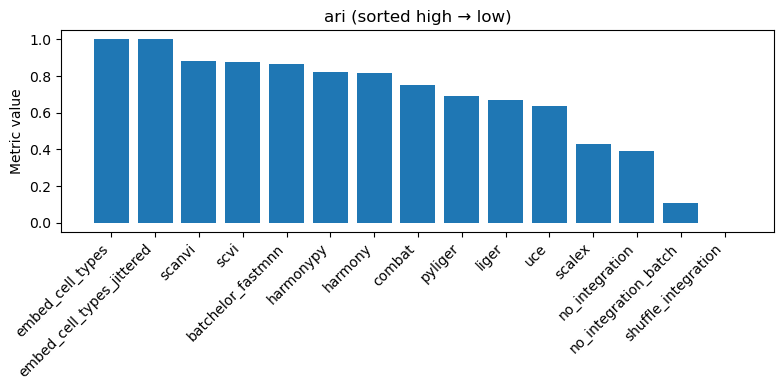

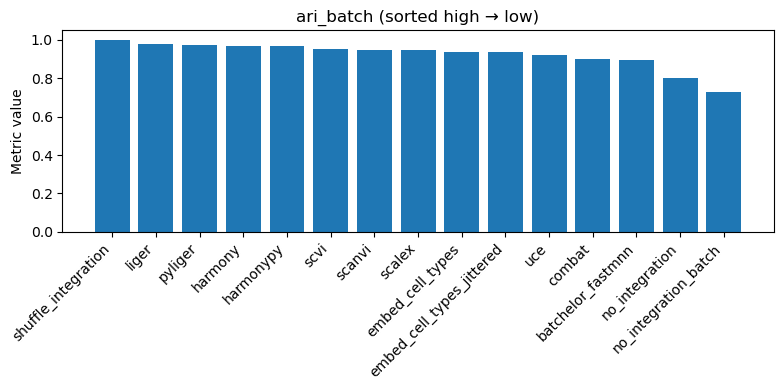

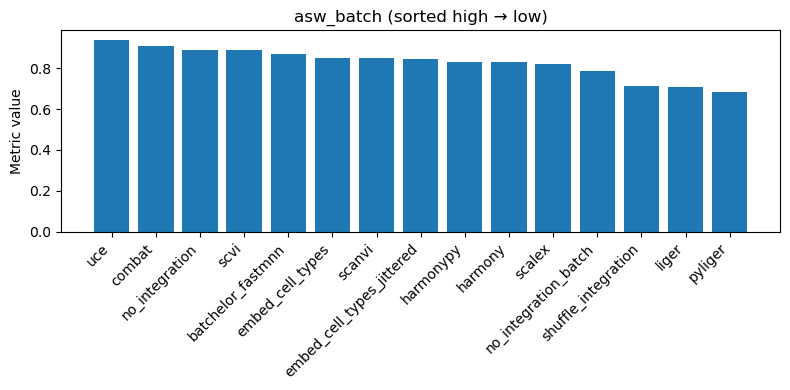

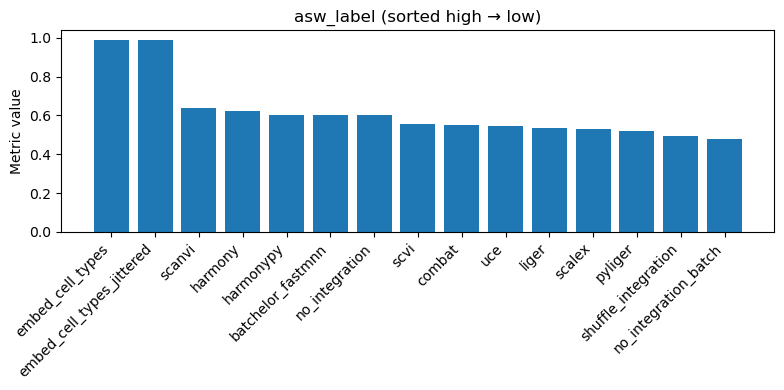

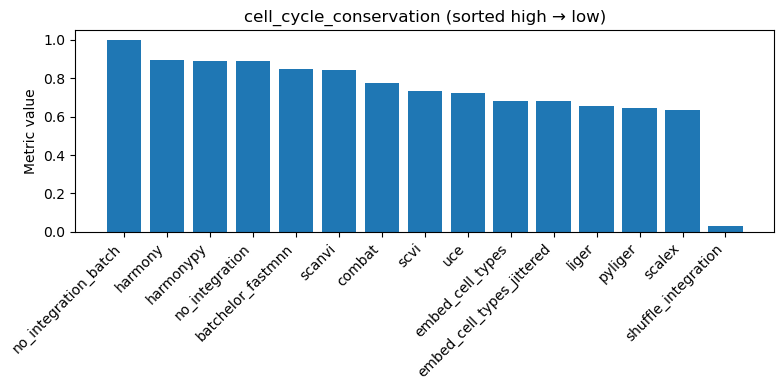

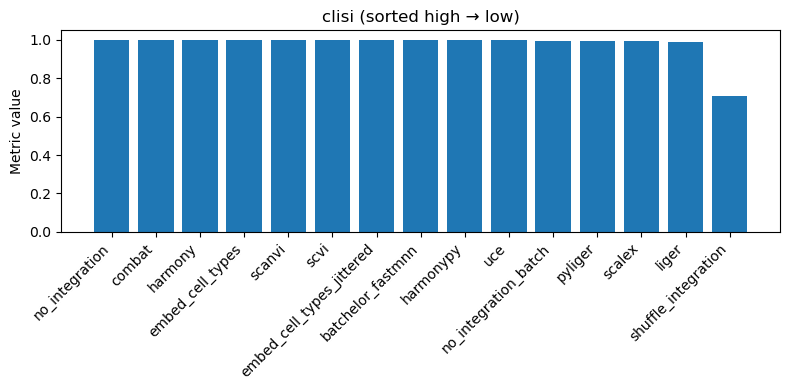

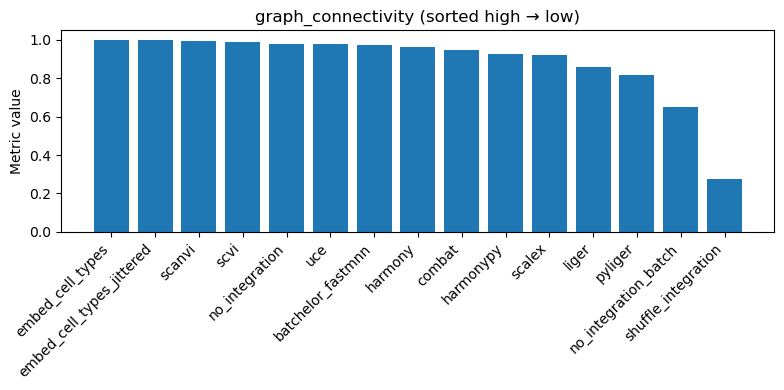

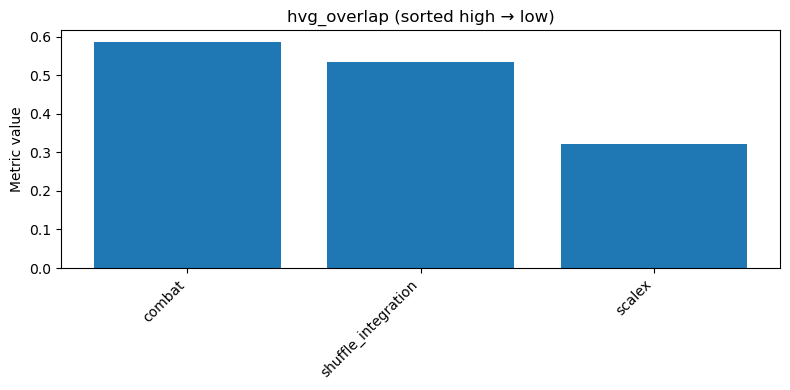

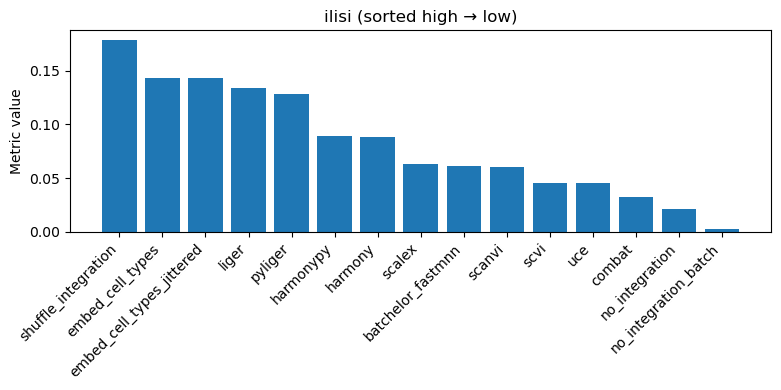

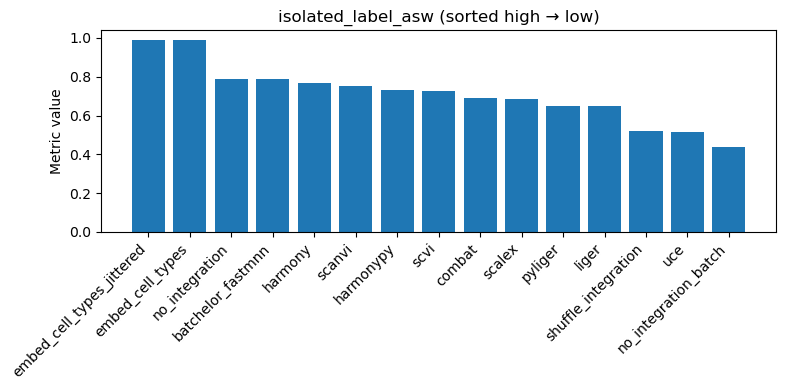

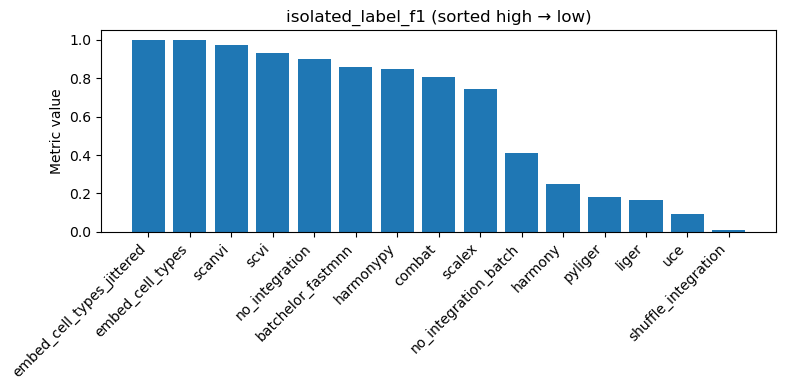

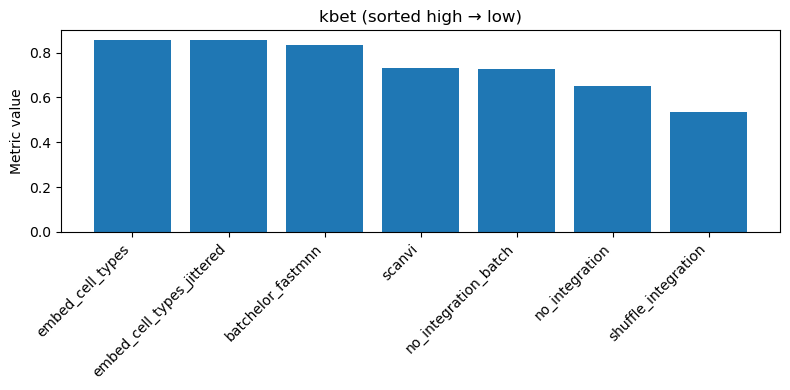

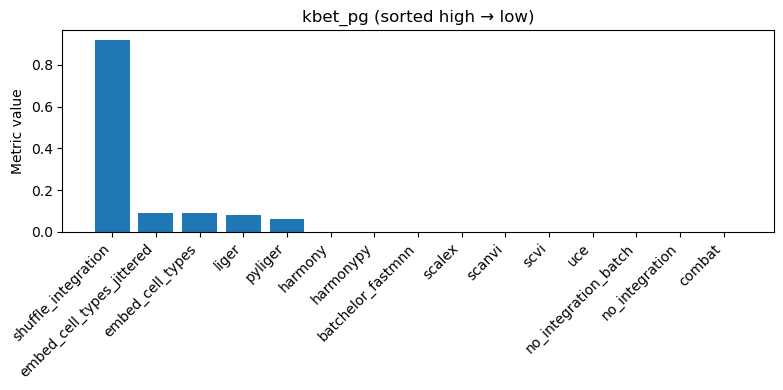

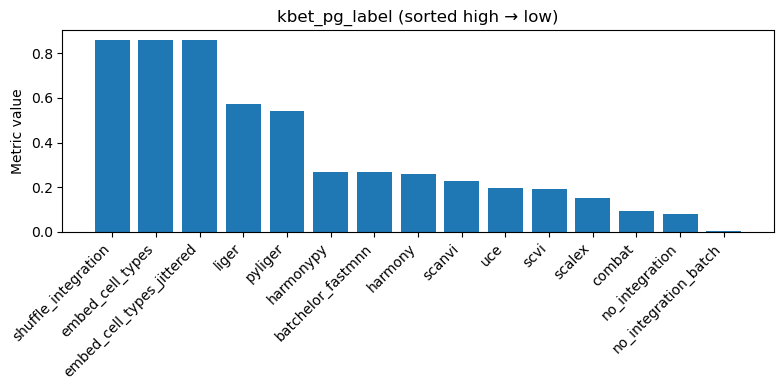

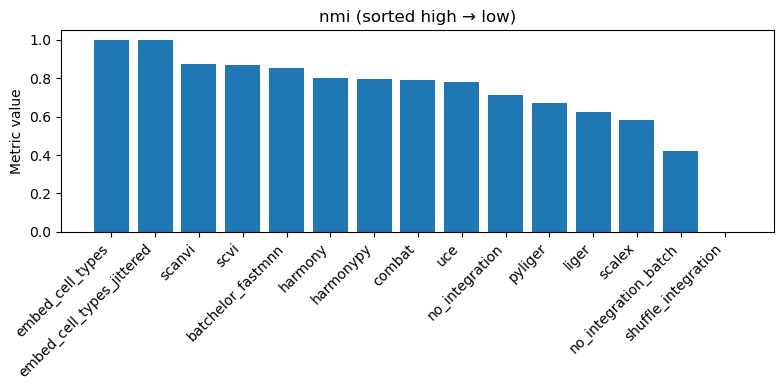

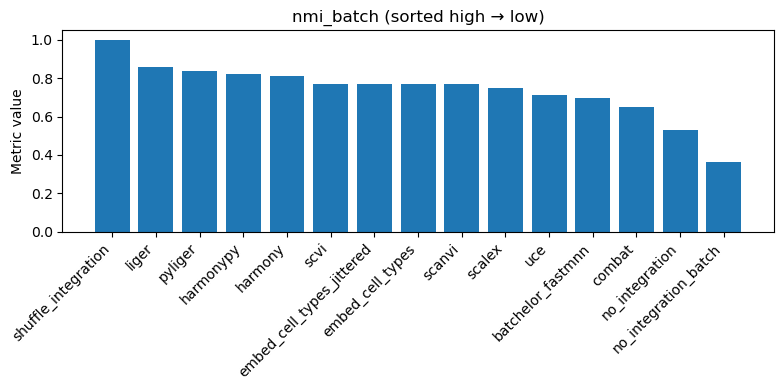

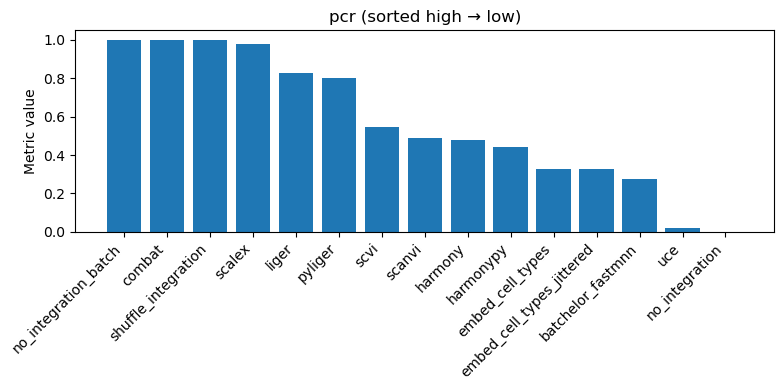

In [25]:
# Loop over each metric
for metric, sub in mouse_pan_df.groupby("metric_id"):
    sub_sorted = sub.sort_values("metric_value", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(sub_sorted["method_id"], sub_sorted["metric_value"])
    plt.title(f"{metric} (sorted high → low)")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Metric value")

    # Save figure per metric
#     safe_metric = metric.replace("/", "_")
#     plt.tight_layout()
#     plt.savefig(f"metric_{safe_metric}.png", dpi=150)
#     plt.close()

    plt.tight_layout()

    plt.show()  # display interactively

# print("✅ All metric bar plots saved as metric_<name>.png")

### Best and Worst Methods

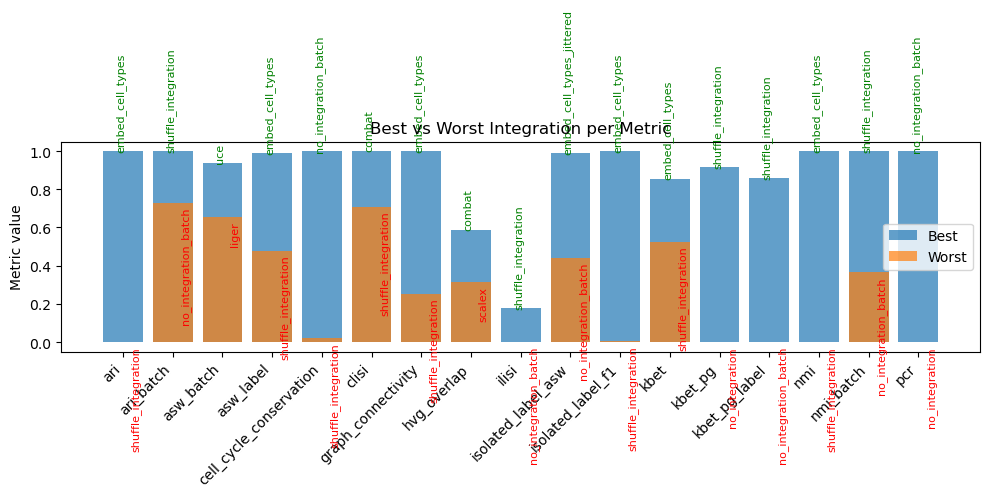

In [28]:
# Find best and worst methods for each metric
best_methods = mouse_pan_df.loc[mouse_pan_df.groupby("metric_id")["metric_value"].idxmax()]
worst_methods = mouse_pan_df.loc[mouse_pan_df.groupby("metric_id")["metric_value"].idxmin()]

plt.figure(figsize=(10, 5))

plt.bar(best_methods["metric_id"], best_methods["metric_value"], label="Best", alpha=0.7)
plt.bar(worst_methods["metric_id"], worst_methods["metric_value"], label="Worst", alpha=0.7)

# Add method names as labels above the bars
for i, (metric, val, method) in enumerate(zip(best_methods["metric_id"], best_methods["metric_value"], best_methods["method_id"])):
    plt.text(i - 0.15, val + 0.01, method, rotation=90, fontsize=8, color="green")

for i, (metric, val, method) in enumerate(zip(worst_methods["metric_id"], worst_methods["metric_value"], worst_methods["method_id"])):
    plt.text(i + 0.15, val - 0.02, method, rotation=90, fontsize=8, color="red", va="top")

# Cosmetics
plt.title("Best vs Worst Integration per Metric")
plt.ylabel("Metric value")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Thoughts: ASW_batch has high metric scores for all of the methods. Let's look into no_integration_batch - this one is not integrated by batch but still got almost 0.8 with ASW_batch. Is ASW_batch reliable?

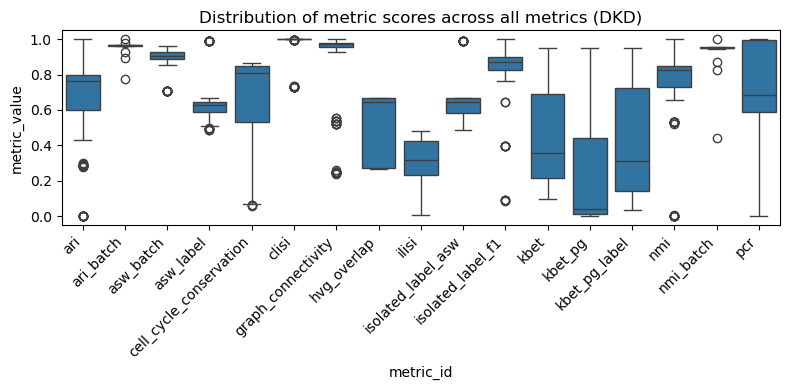

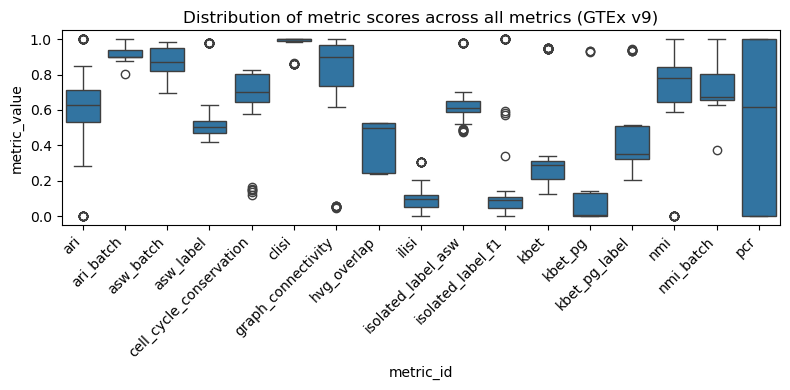

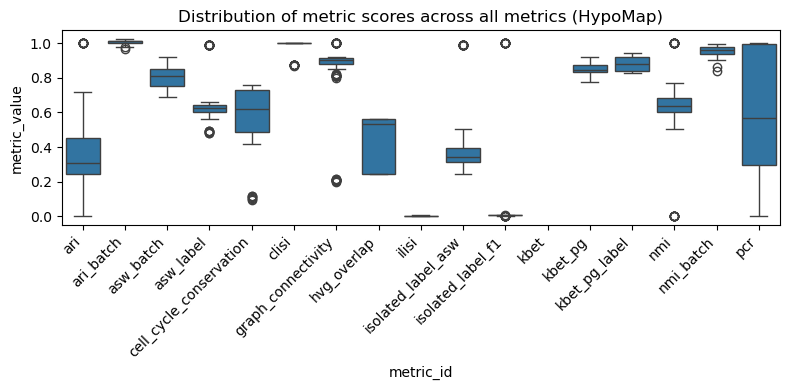

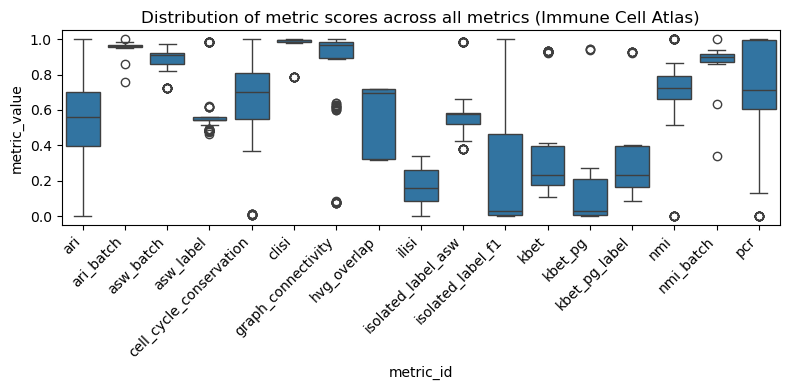

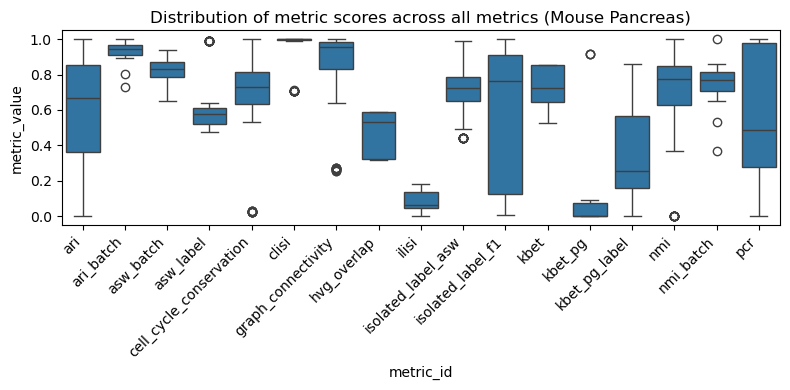

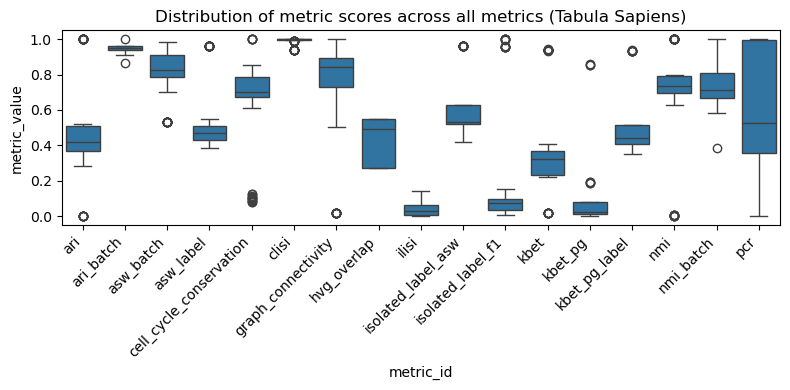

In [33]:
metric_order = sorted(
    set().union(*[df["metric_id"].unique() for df in datasets.values()])
)

for name, df in datasets.items():
    plt.figure(figsize=(8,4))
    sns.boxplot(x="metric_id", y="metric_value", data=df, order=metric_order)
    plt.title(f"Distribution of metric scores across all metrics ({name})")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

e.g. ari_batch performed very well in every datasets

### Adding dataset characteristics to the big df

In [69]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Tabellenblatt2.csv")
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # make them the same name to merge

print(meta["dataset"].unique())
print(df["dataset_id"].unique())

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

['mouse_pancreas_atlas' 'dkd' 'immune_cell_atlas' 'gtex_v9' 'hypomap'
 'tabula_sapiens']
['zebrafish' 'dkd' 'tabula_sapiens' 'pancreas' 'mouse_pancreas_atlas'
 'cengen' 'gtex_v9' 'hypomap' 'immune_cells' 'immune_cell_atlas']


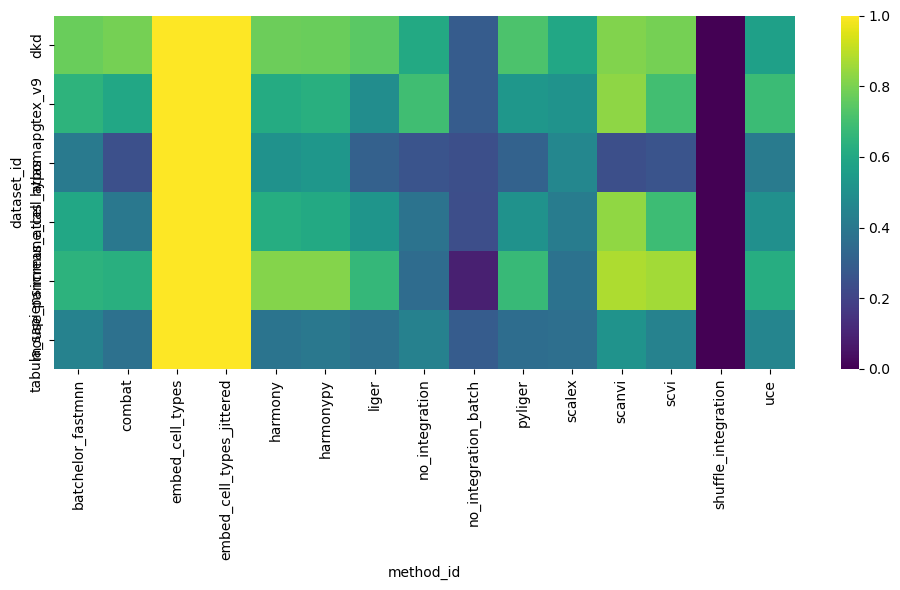

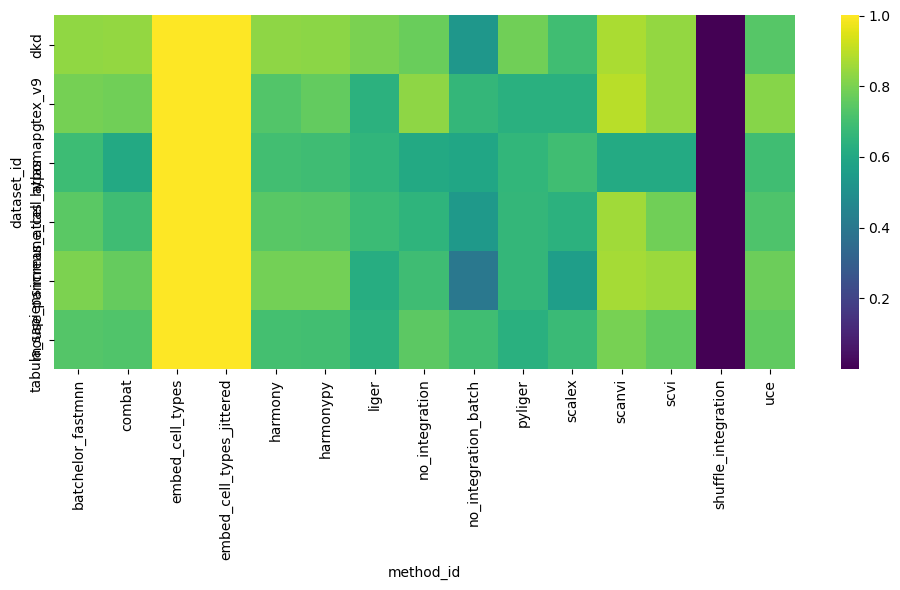

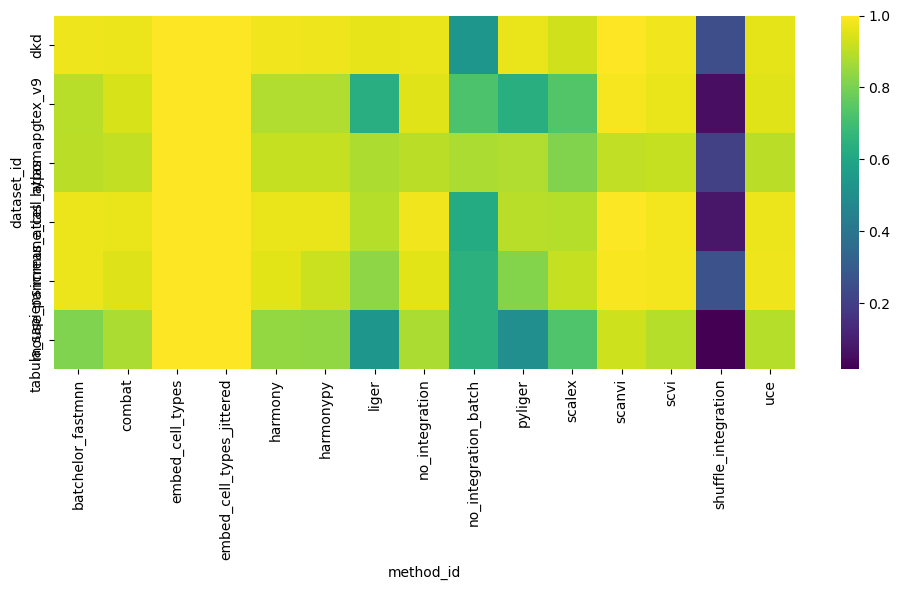

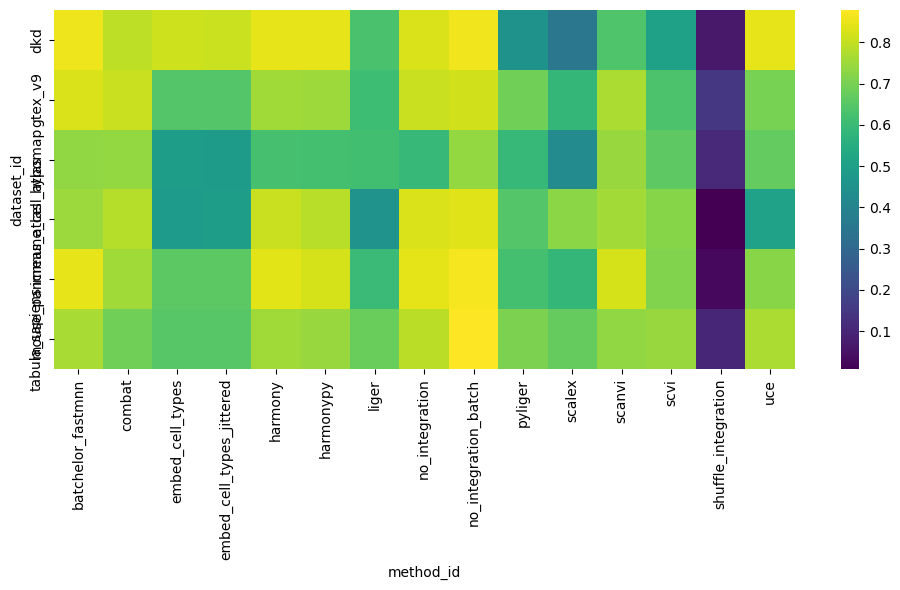

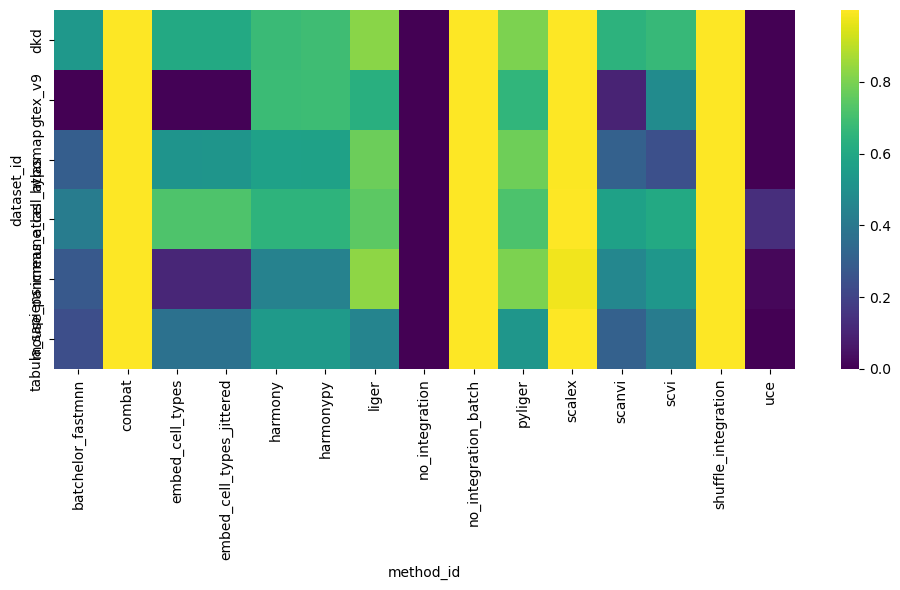

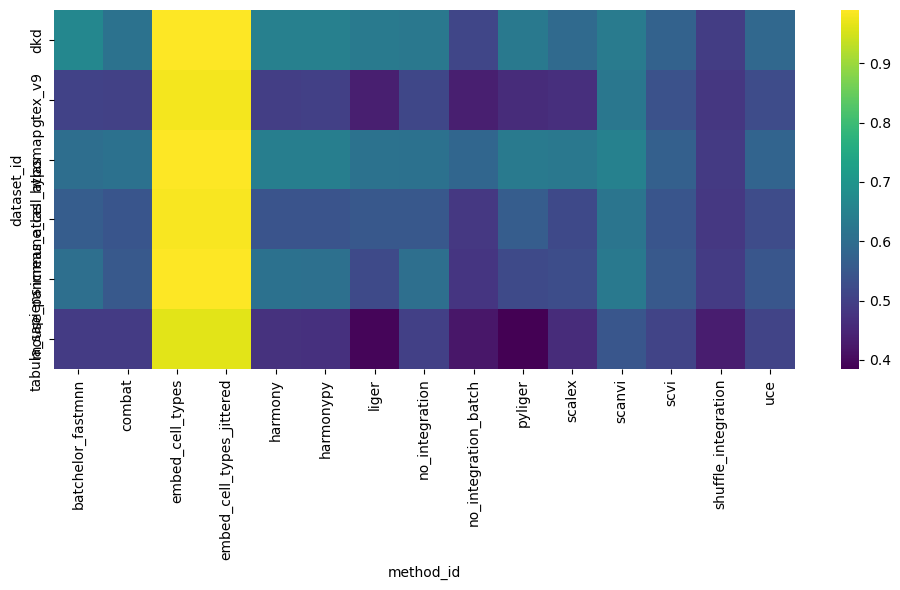

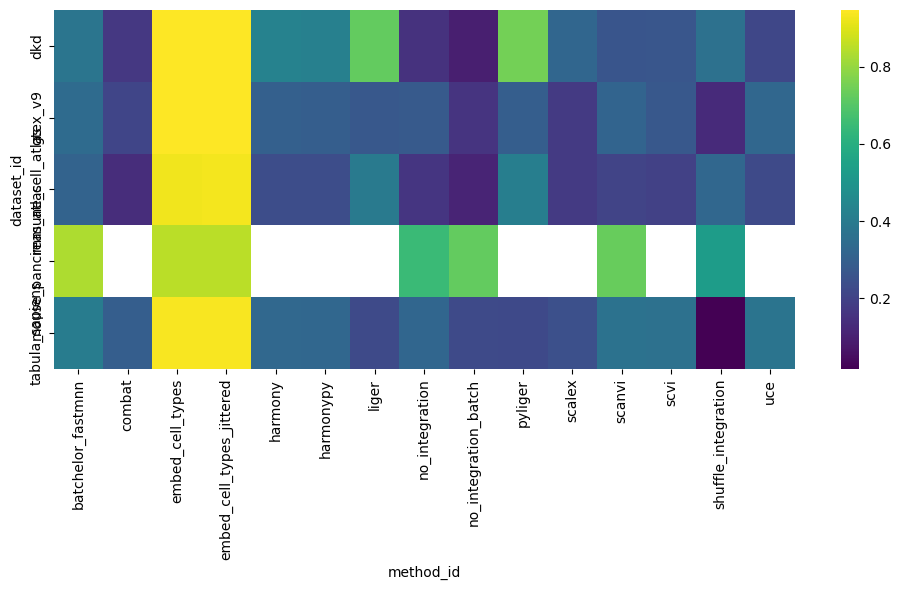

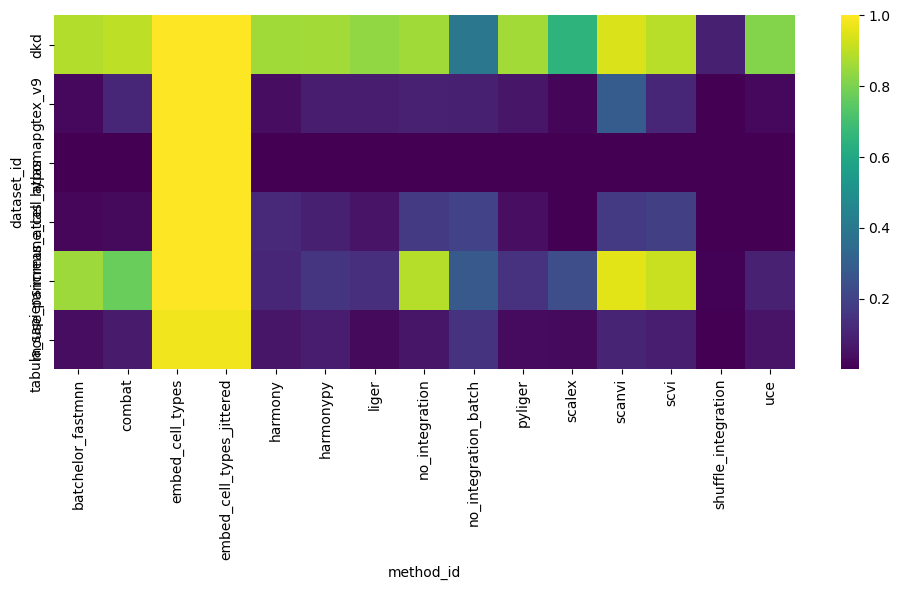

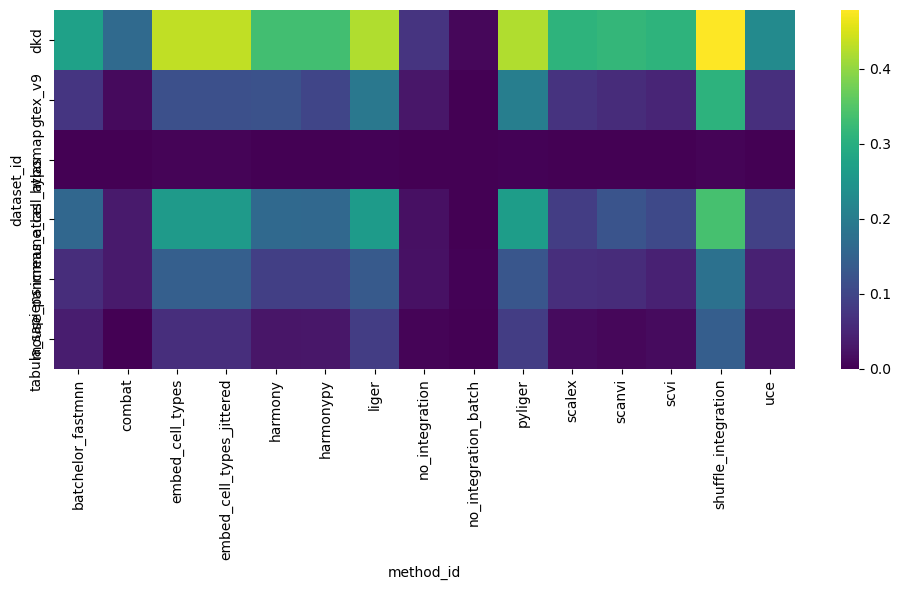

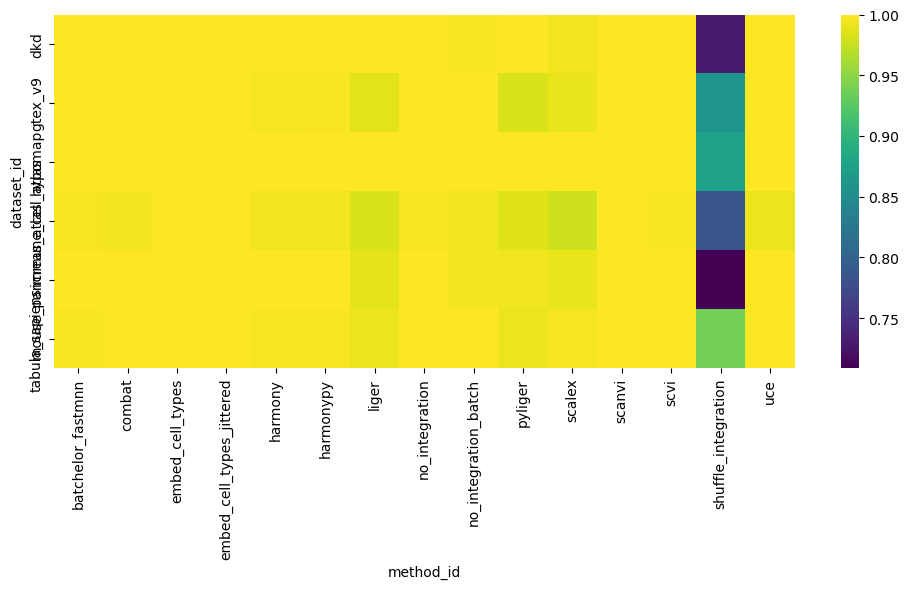

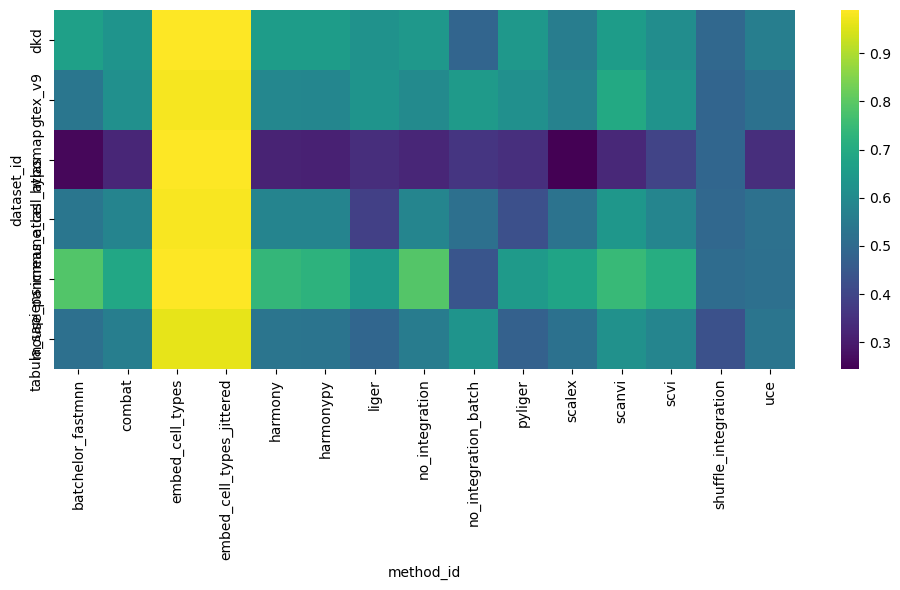

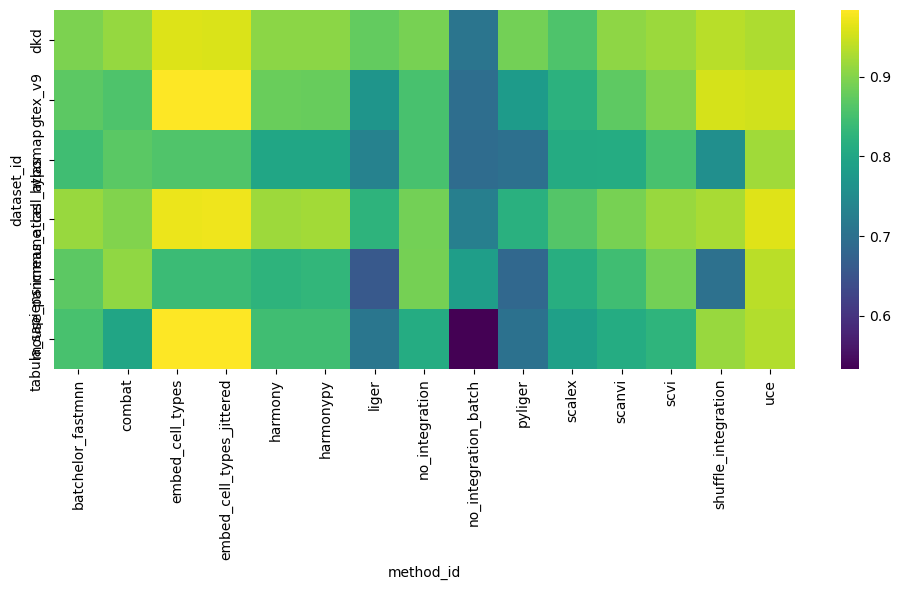

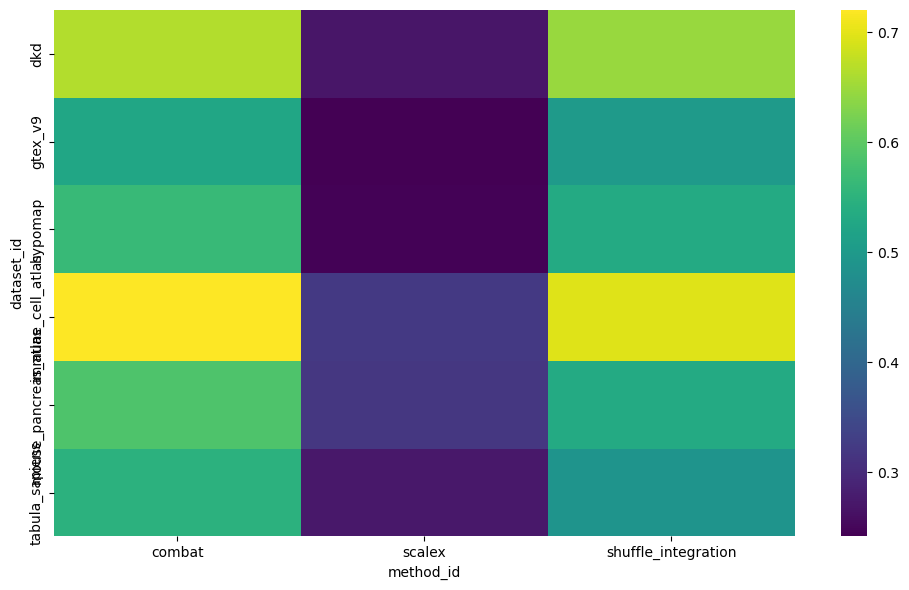

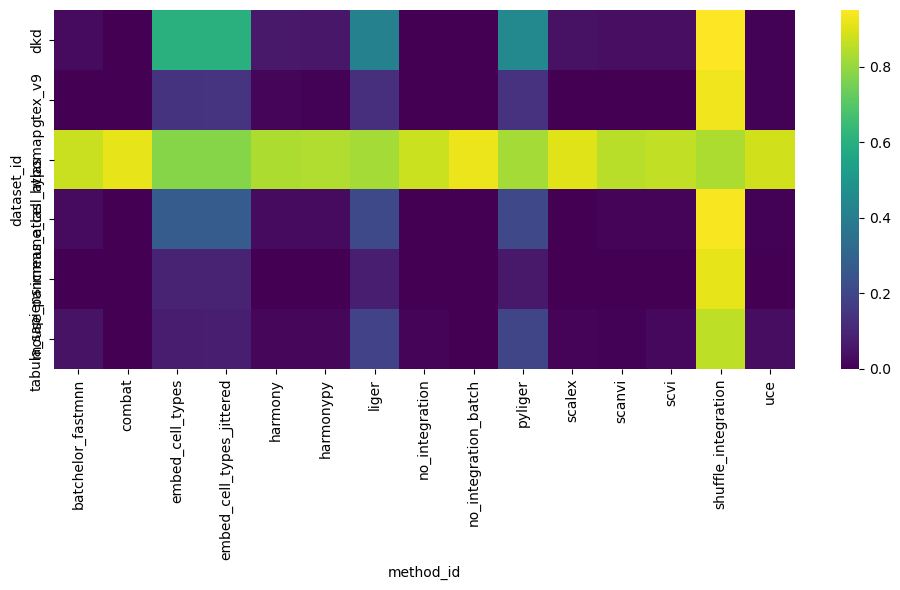

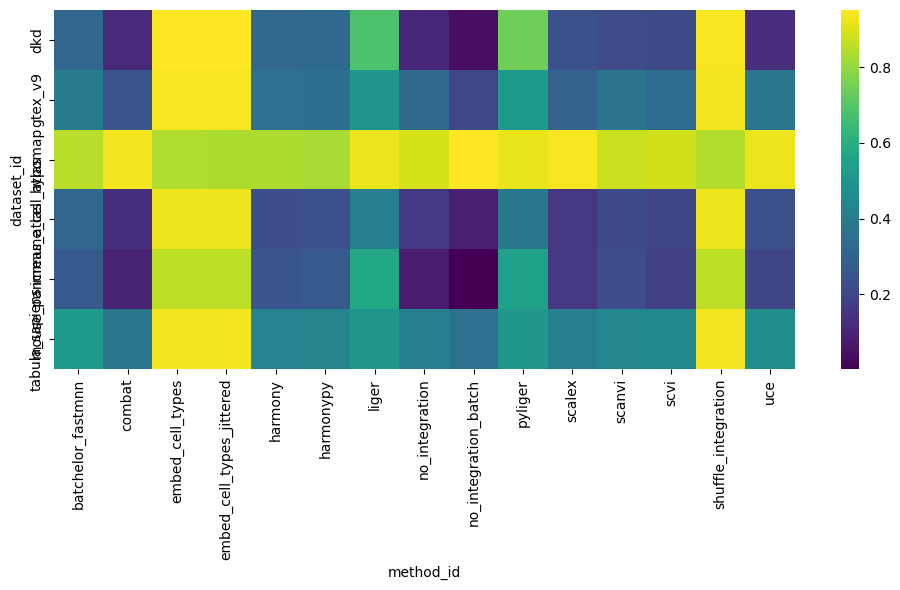

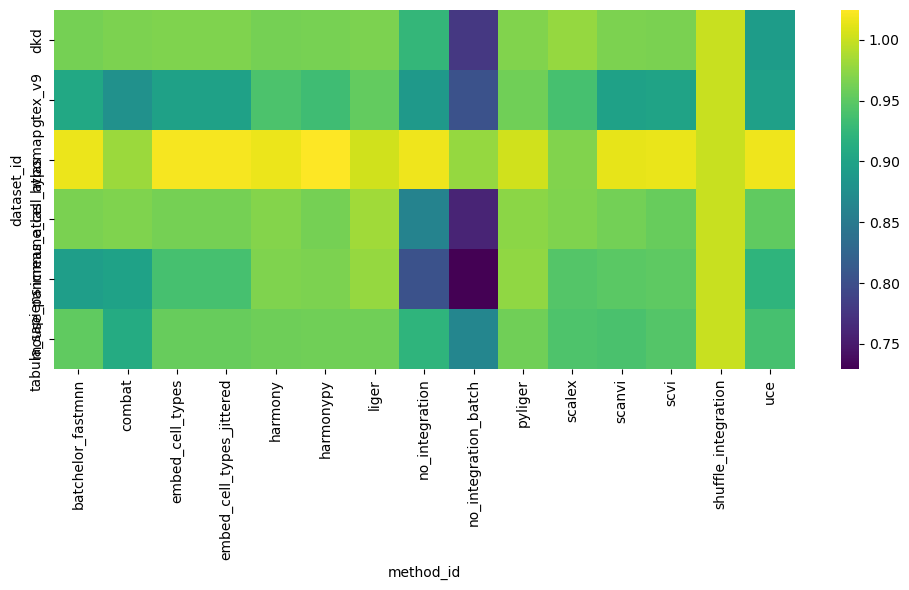

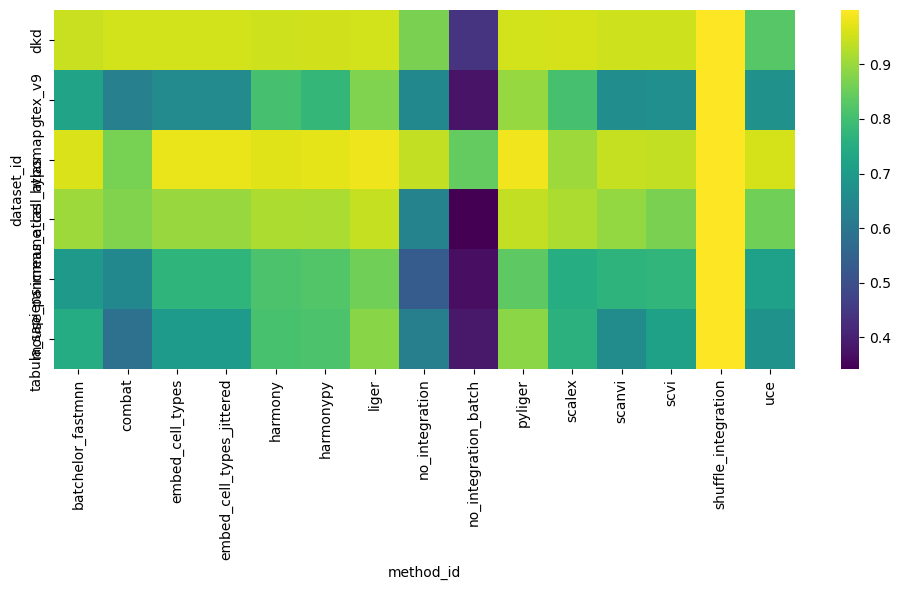

In [70]:
for metric in df["metric_id"].unique():
    sub = df[df["metric_id"] == metric]

    pv = sub.pivot_table(
        index="dataset_id",
        columns="method_id",
        values="metric_value",
        # aggfunc="first"   # use raw values (no averaging)
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pv, cmap="viridis", ax=ax)
    
    ax.tick_params(axis="y", labelrotation=90) # doesn't work I give up
    
    plt.tight_layout()
    plt.show()

### Metric dependence on dataset characteristics

In [71]:
df.columns

Index(['dataset_id', 'file_size', 'method_id', 'normalization_id', 'metric_id',
       'metric_value', 'organism', 'tissue', 'size', 'n_genes', 'n_celltypes',
       'n_batches', 'batch_imbalance', 'nested_batches', 'n_samples',
       'n_donors'],
      dtype='object')

<Axes: >

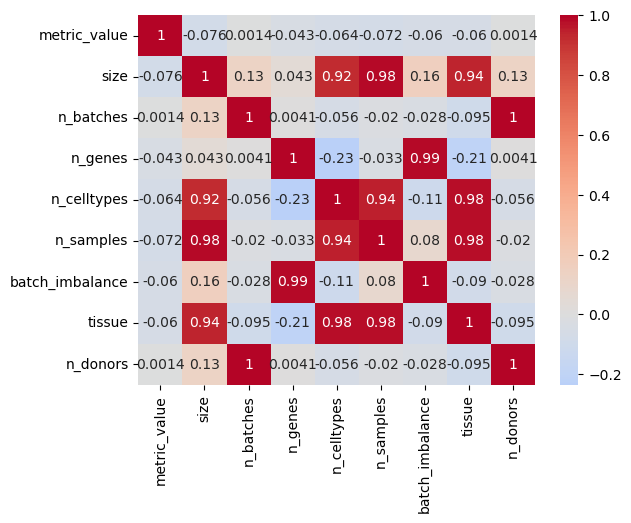

In [74]:
num_cols = ["metric_value","size","n_batches","n_genes","n_celltypes","n_samples","batch_imbalance","tissue","n_donors"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

so... kind of.. around 0 with metric value.. no correlation?


### metric value vs number of cells

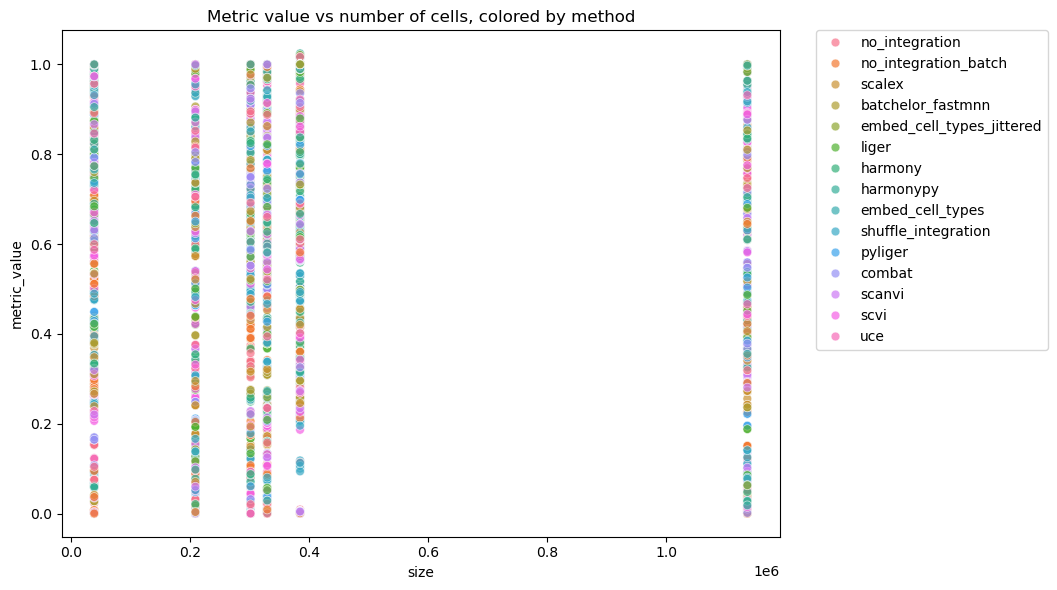

In [80]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="size",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of cells, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

Can't really see where I'd like to zoom in

### metric value - n_genes

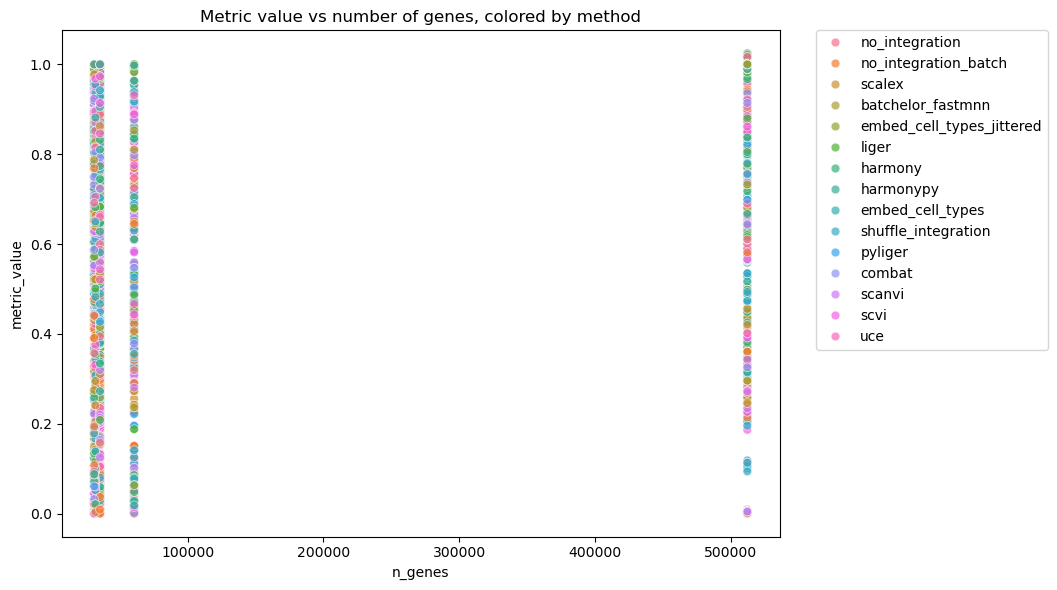

In [86]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="n_genes",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of genes, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

### metric value - tissue

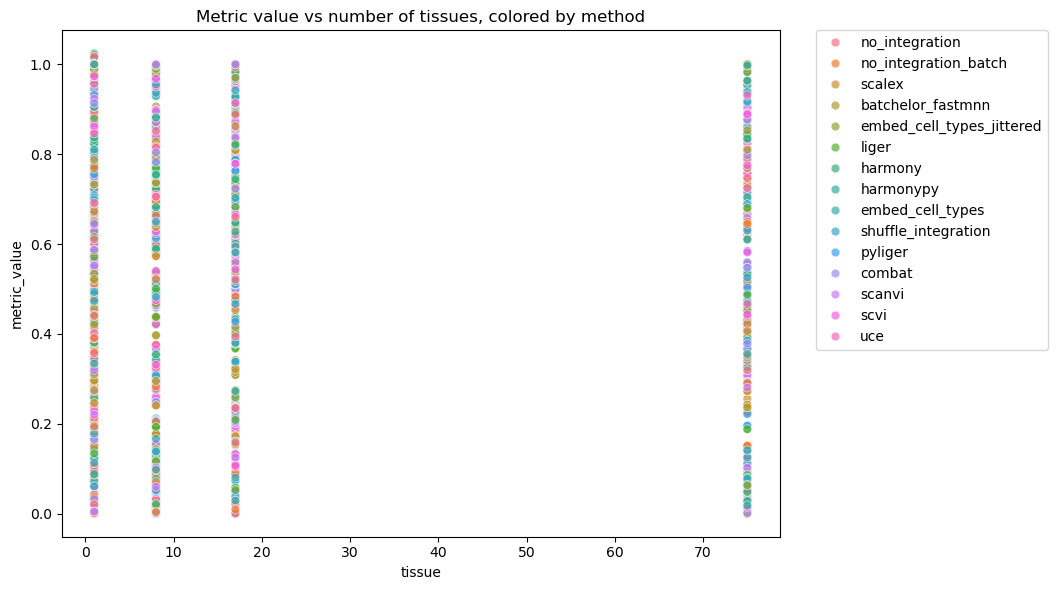

In [87]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="tissue",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of tissues, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

### Metric value - number of Batches

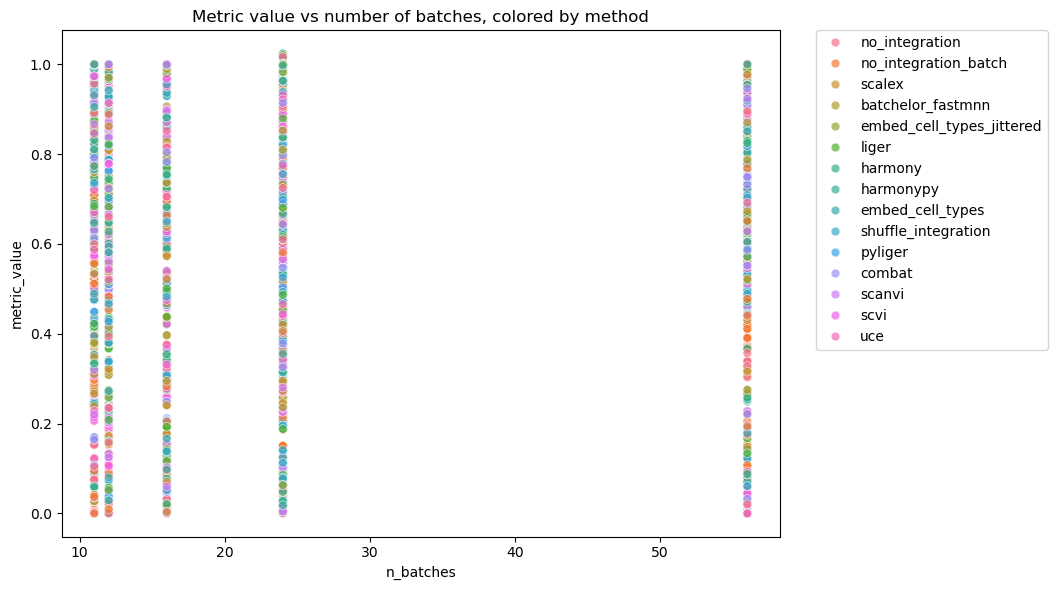

In [88]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="n_batches",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of batches, colored by method")
plt.tight_layout()

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.show()

=> separate plot per metric or color by metric instead of method

### Colored by metric: metric value - number of cells

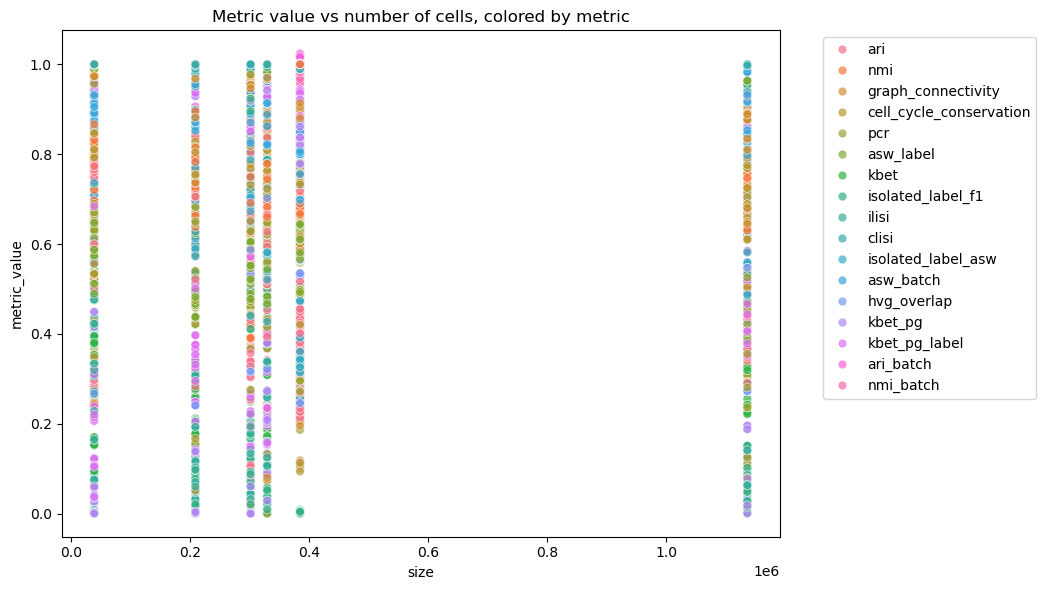

In [90]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="size",
    y="metric_value",
    hue="metric_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs number of cells, colored by metric")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### metric value - nested batches

In [91]:
df["nested_batches"] = (
    df["nested_batches"]
    .fillna("Unknown")            # replace NaN with "Unknown"
    .astype(str)                  # ensure string
    .str.capitalize()             # make it 'Yes', 'No', 'Unknown'
)

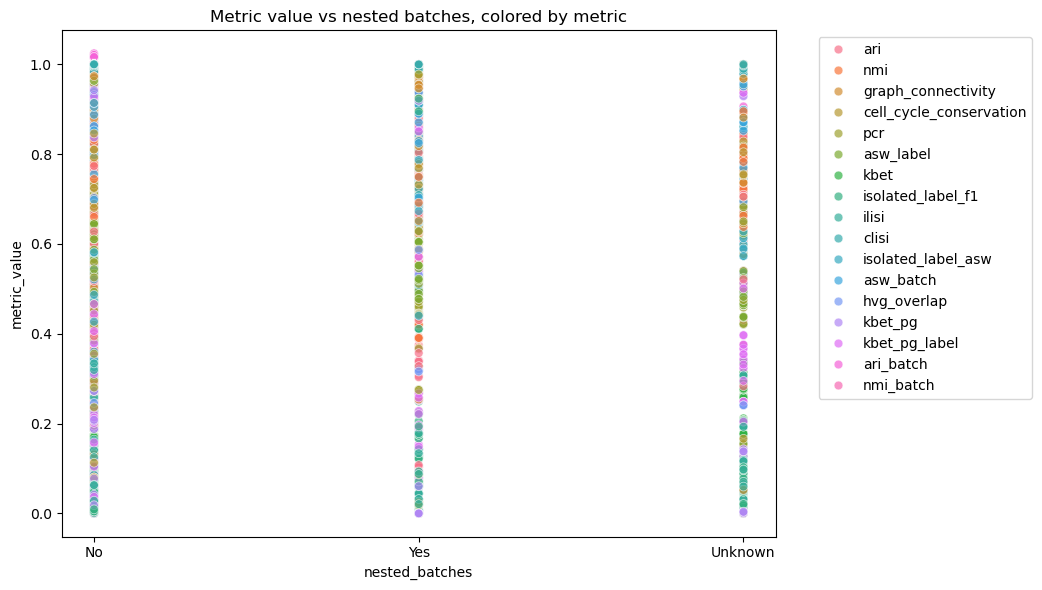

In [95]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="nested_batches",
    y="metric_value",
    hue="metric_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs nested batches, colored by metric")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


### batch imbalance

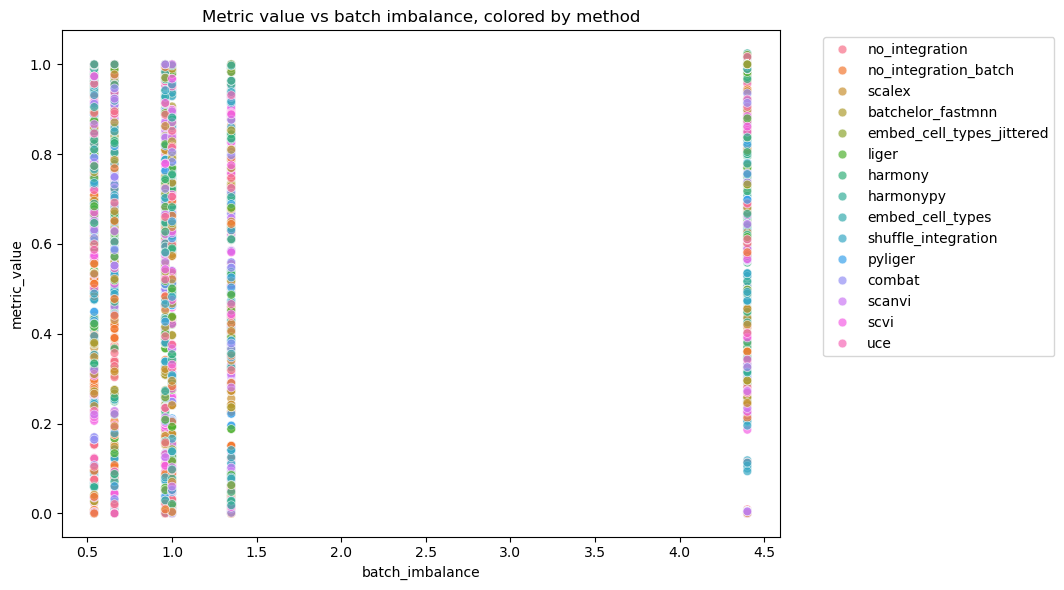

In [96]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="batch_imbalance",
    y="metric_value",
    hue="method_id",
    alpha=0.7,
    s=40
)

plt.title("Metric value vs batch imbalance, colored by method")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

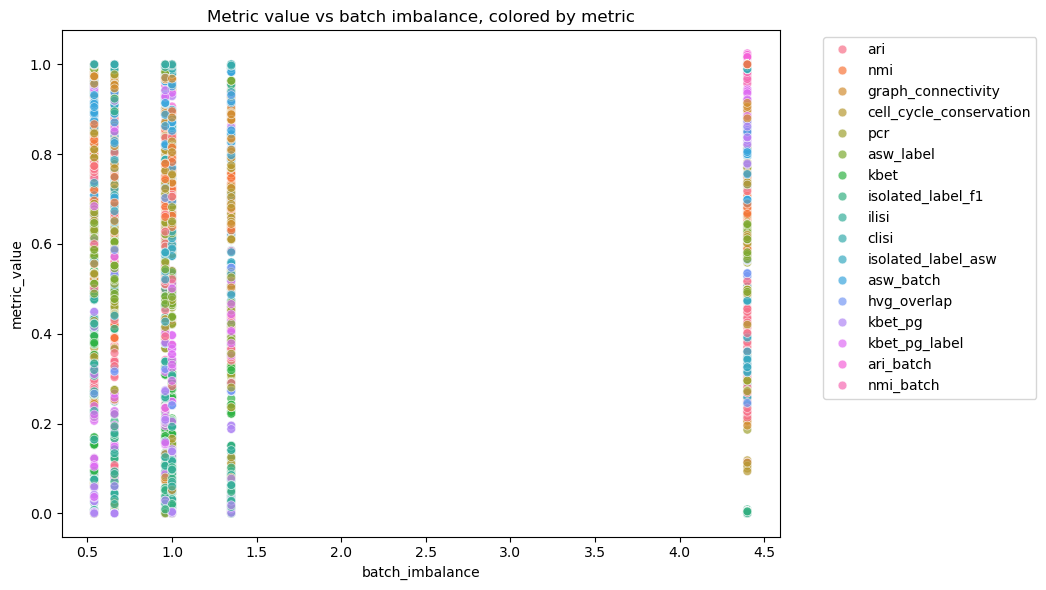

In [98]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df,
    x="batch_imbalance",
    y="metric_value",
    hue="metric_id",      # <-- color by metric
    alpha=0.7,
    s=40
)

plt.title("Metric value vs batch imbalance, colored by metric")
plt.tight_layout()

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Performance per Organism

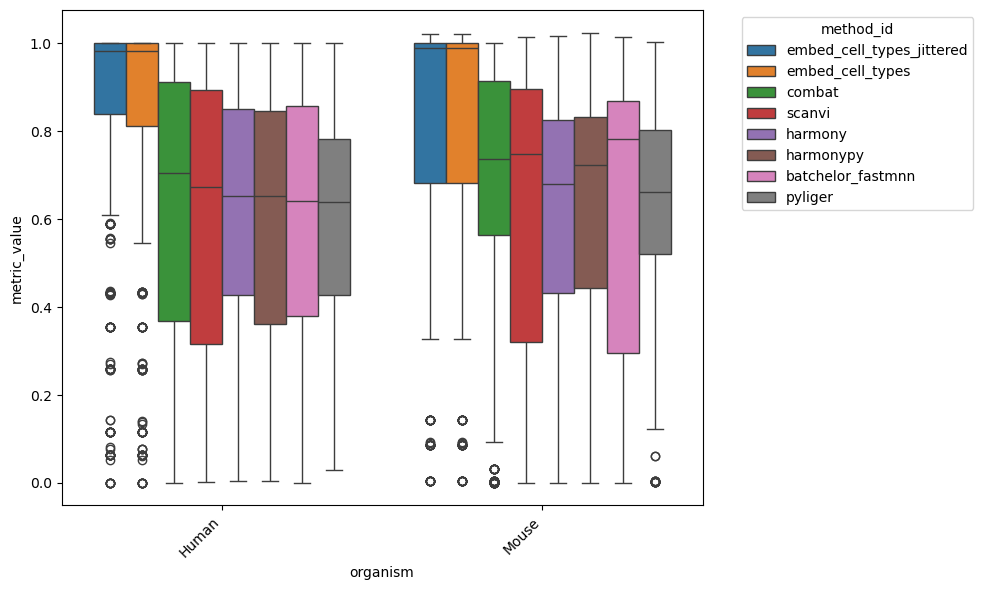

In [99]:
# Compute average metric per method to order them
order = df.groupby("method_id")["metric_value"].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(
    x="organism", y="metric_value", hue="method_id",
    data=df, order=None, hue_order=order[:8]  # show only top 8 methods
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="method_id")
plt.tight_layout()
plt.show()